# SPH Simulation

Fluids play an important role in our daily life. Fluids are everywhere and are not restricted to water. Fluid phenomena can be observed in many different contexts, such as wind, water, ocean currents, and even in the human body. 

In this notebook, we will implement a simple fluid simulation using the Smoothed Particle Hydrodynamics (SPH) method. SPH is a particle-based method for simulating fluid flows.

## Table of Contents

- [Imports](#Imports) – Basic import statements  
- [Big Picture](#Big-Picture) – Overview of the simulation goals  
- [Particle](#Particle) – Definition of the particle class  
- [Visualizations](#Visualizations) – 2D visualization of particles  
- [Density Calculation](#Density-calculation) – Computing the density field  
- [Pressure Calculation](#Pressure-calculation) – Deriving the pressure field and forces  
- [Viscosity Calculation](#Viscosity-calculation) – Adding viscosity to the simulation
- [Grid](#Grid) – Accelerating calculations with a spatial grid  
- [Time Integration](#Time-integration) – Updating simulation over time, handling boundaries and animate the simulation
- [References](#References) – References and further reading

## Imports

In [1]:
import time
import itertools
import numpy as np
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import HTML, Video

## Big Picture

The following video showcases what is possible with the SPH method described in this notebook. The video shows an example with 15000 particles and uses CUDA to accelerate the simulation. The video is not part of this notebook, but it gives an idea of what we are trying to achieve.

In this Notebook, we will simulate a simple fluid with 150 particles since our implementation will run on the CPU. But the formulars and the method are exactly the same as in the video.

If you have a CUDA-capable GPU, you can check out the [SPH CUDA implementation](https://github.com/ProfessorNova/SPH-CUDA) of this project to run the simulation on the GPU in order to achieve real-time performance like in the video.

To give a roadmap of the notebook, we will start with a simple particle class that will represent the fluid particles. Then we will implement the SPH method step by step. We will start with the density calculation, then move on to pressure calculation, viscosity calculation, and finally time integration. We will also implement a simple grid to accelerate the calculations. Finally, we will animate the simulation using Matplotlib.

In [2]:
# Video("../docs/preview.mp4", embed=True, width=800, height=600)

# Particle

Let's create a class called `Particle` which can carry the three quantities `mass`, `position` and `velocity`. 
We will also add the attributes `density`and `pressure` to the class, which will be used to store the density and pressure at the particle location.
Since these quantities need to be evaluated first, we will initialize them with `None`.
Lastly, we will add a buffer `accumulated_force` for forces acting on the particle, which will be used to store the forces acting on the particle during the simulation.

In [3]:
class Particle:
    def __init__(self, position: np.ndarray, velocity: np.ndarray, mass: float=1.0):
        self.position = position
        self.velocity = velocity
        self.mass = mass
        self.density = None # density at the particle's position
        self.pressure = None # pressure at the particle's position
        self.accumulated_force = None # accumulated force acting on the particle

We will create a global list of particles called `particles` which will be used to store all the particles in the simulation. Furthermore, we are going to introduce some Hyperparameters:

- `N` is the number of Particles used in the simulation.

- `PARTICLE_MASS` is the mass of one particle. Thus, the total mass of the fluid is `N` times `PARTICLE_MASS`.

- `DIMENSIONS` is the number of dimensions used in the simulation. The visualisations we use expect 2 dimensions. But the maths is exactly the same for any number of dimensions. 

- `DIMENSION_SIZES` how far the simulation domain extends in each dimension.

In [4]:
# Define N, DIMENSIONS and DIMENSION_SIZES
N = 100
PARTICLE_MASS = 1.0 # kg (fluid mass is N * PARTICLE_MASS)
DIMENSIONS = 2 # 2D simulation
DIMENSION_SIZES = np.array([2.0, 1.0]) # meters
assert len(DIMENSION_SIZES) == DIMENSIONS

In [5]:
# Initialize particles
particles: list[Particle] = []
for _ in range(N):
    position = np.random.rand(DIMENSIONS) * DIMENSION_SIZES
    velocity = np.zeros(DIMENSIONS)
    particles.append(Particle(position, velocity, PARTICLE_MASS))

## Visualizations

Next we will define a function that lets us visualize the particles in the simulation. We will use the `matplotlib` library to create a scatter plot of the particles. We will add more visualizations later on to show the density and pressure fields on top of the particles.

We want to have a particle at position (0, 0) to be visualized in the top left corner of the plot. Since scatter plots usually have the origin in the bottom left corner, we will invert the y-axis to have the origin in the top left corner. Furthermore, we will use the colormap `Blues_r` to visualize the velocity of the particles with white being the fastest and blue being the slowest.

In [6]:
def initialize_particle_subplot(fig, ax, particles):
    x = [p.position[0] for p in particles]
    y = [DIMENSION_SIZES[1] - p.position[1] for p in particles] # flip y-axis for matplotlib
    colors = [np.linalg.norm(p.velocity) for p in particles]
    ax.set_xlim(0, DIMENSION_SIZES[0])
    ax.set_ylim(0, DIMENSION_SIZES[1])
    fig.patch.set_facecolor('black')
    ax.set_aspect('equal')
    ax.axis('off')
    ax.scatter(x, y, c=colors, cmap='Blues_r', s=100, vmin=0, vmax=100)

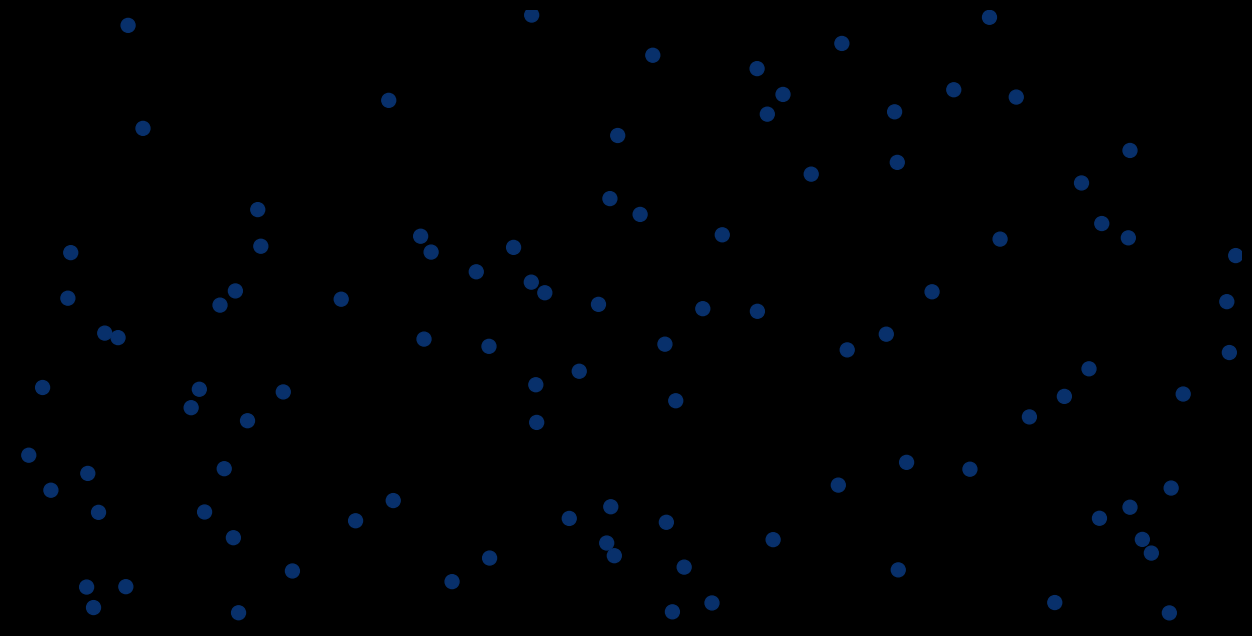

In [7]:
# Plot particles
fig, ax = plt.subplots(figsize=(8 * DIMENSION_SIZES[0] / DIMENSION_SIZES[1], 8))
initialize_particle_subplot(fig, ax, particles)
plt.show()

## Density calculation

Density at a point in space increases with the number of particles around it and how close each of them is. This poses the question of how the distance exactly influences the density at a point in space. This relationship is usually modeled using a kernel function $W(\mathbf{r}, h)$, where $\mathbf{r}$ is a position vector and $h$ is the constant called smoothing radius which we will shortly define.

It is very important that the kernel function fulfills the following properties:

- $W(\mathbf{r}, h) = W(-\mathbf{r}, h)$ (symmetry)

- $\int W(\mathbf{r}) \, d\mathbf{r} \;=\; 1$ (normalization)

The kernel function being symmetric means that the density at a point is the same no matter from which direction the particles are coming.

The part with the normalization is important because it each particle represents a certain amount of mass. The mass of the particle is distributed over the area defined by the smoothing radius. The total mass of the particle should be conserved, so the sum of the kernel function over the entire area should be equal to 1. Otherwise, the mass would be lost or created out of nowhere.

Of course, you can also go ahead and define your own kernel function and I also encourage you to do so if you are interested in the topic. For this example, we will use the poly6 kernel function for the density calculation. The poly6 kernel function is defined as follows:

$W_{\mathrm{poly6}}(\mathbf{r},h) = \dfrac{315}{64 \pi h^{9}} \begin{cases} \bigl(h^2 - r^2\bigr)^{3} & 0 \leq r \leq h \\ 0 & \text{otherwise} \end{cases}$

In [8]:
# Define H
H = 0.15 # m

In [9]:
def W_poly6(r: np.ndarray, h: float=H) -> float:
    r_len = np.linalg.norm(r) # Turn r into a scalar
    if 0 <= r_len <= h:
        return 315 / (64 * np.pi * h**9) * (h**2 - r_len**2)**3
    else:
        return 0.0

Let's check if the kernel function fulfills the properties we defined above. 

The symmetry property is easy to check since r is squared and will be the same for negative and positive values. 

The normalization property is a bit more complicated. We need to integrate the kernel function over the entire area defined by the smoothing radius. For this, we will use the `scipy` library to perform the integration. It is important to note that we need to use spherical coordinates for the integration. This is because the kernel function is defined in 3D space. For more information on spherical coordinates, check out the [Wikipedia article](https://en.wikipedia.org/wiki/Spherical_coordinate_system).

In [10]:
def check_poly6_normalization():
    r = sp.Symbol("r", nonnegative=True)
    h = sp.Symbol("h", positive=True)
    
    # Define the poly6 kernel
    W = 315 / (64 * sp.pi * h**9) * (h**2 - r**2)**3
    
    # Volume element in spherical coordinates: 4*pi*r^2
    integrand = W * 4*sp.pi*r**2
    
    # Integrate from r=0 to r=h
    integral_value = sp.integrate(integrand, (r, 0, h))
    
    # Simplify the expression
    return sp.simplify(integral_value)

print("Normalization check of W_poly6(r):")
print("Integral of W(r) over volume =", check_poly6_normalization())

Normalization check of W_poly6(r):
Integral of W(r) over volume = 1


Let's plot the poly6 kernel function to get a feeling for how it looks like. You will see that at the smoothing radius $h$ the function reaches 0. This ensures that there is no hard cut-off at the smoothing radius. Furthermore, the function has a maximum at $r=0$ at with a value of $\dfrac{315}{64 \pi h^{9}}$. This means that the density will be highest at the particle itself and decrease with the distance from the particle, effectively creating a smooth density field around the particle.

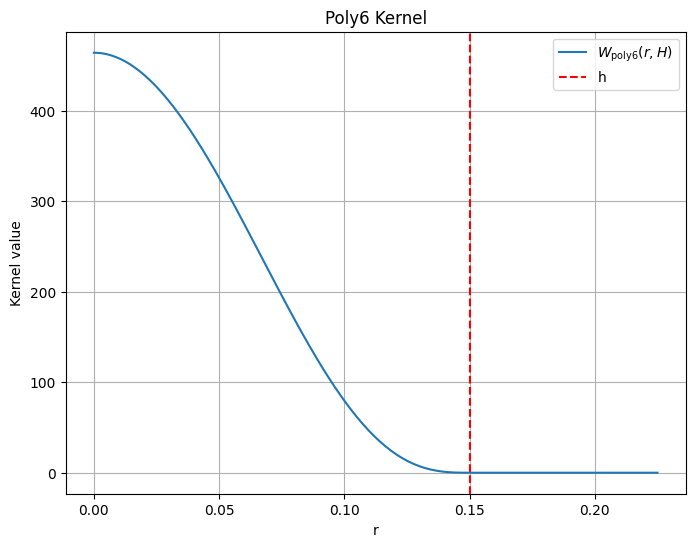

In [11]:
# We only need positive values of r since distances are always positive
r_vals = np.linspace(0, 1.5 * H, 200)
values = [W_poly6(np.array([r, 0]), H) for r in r_vals]

plt.figure(figsize=(8, 6))
plt.plot(r_vals, values, label=r'$W_{\mathrm{poly6}}(r,H)$')
plt.axvline(x=H, linestyle='--', color='red', label='h')
plt.xlabel("r")
plt.ylabel("Kernel value")
plt.title("Poly6 Kernel")
plt.legend()
plt.grid(True)
plt.show()

Now we can begin with the actual density calculation. The density at a point in space is calculated by summing up the mass of all particles around it. The mass of each particle is weighted by the kernel function at the distance between the particle and the point in space. The density $\rho$ at a point in space is then given by the following formula:

$\rho_s(\mathbf{r}) = \sum_{j} \, m_j \, W\bigl(\mathbf{r} - \mathbf{r}_j, h\bigr)$

In [12]:
def roh_s(r: np.ndarray) -> float:
    density = 0.0
    for j in particles:
        density += j.mass * W_poly6(r - j.position, H)
    return density

Let's take a look at the density field of the particles. We calculate the density at each point on a grid and visualize it using a imshow plot. When looking at the density field we can see that the density is highest at the particles and decreases with the distance from the particles. The density is especially high when more particles are close together. The density field is smooth and continuous, which is a result of the kernel function we used. The density field is also symmetric around each particle, which is a result of the symmetry property of the kernel function. This is exactly what we want.

I encourage you to play around with the smoothing radius `H`. If you set the smoothing radius to the size of the simulation domain it will enclose the whole area and the density field will be one big blob in the middle of the plot. This is because the spot where the average distance to each particle is the smallest should be relatively in the middle of the plot. If you set the smoothing radius very low there will only be density around the particles and the density will be zero in between the particles.

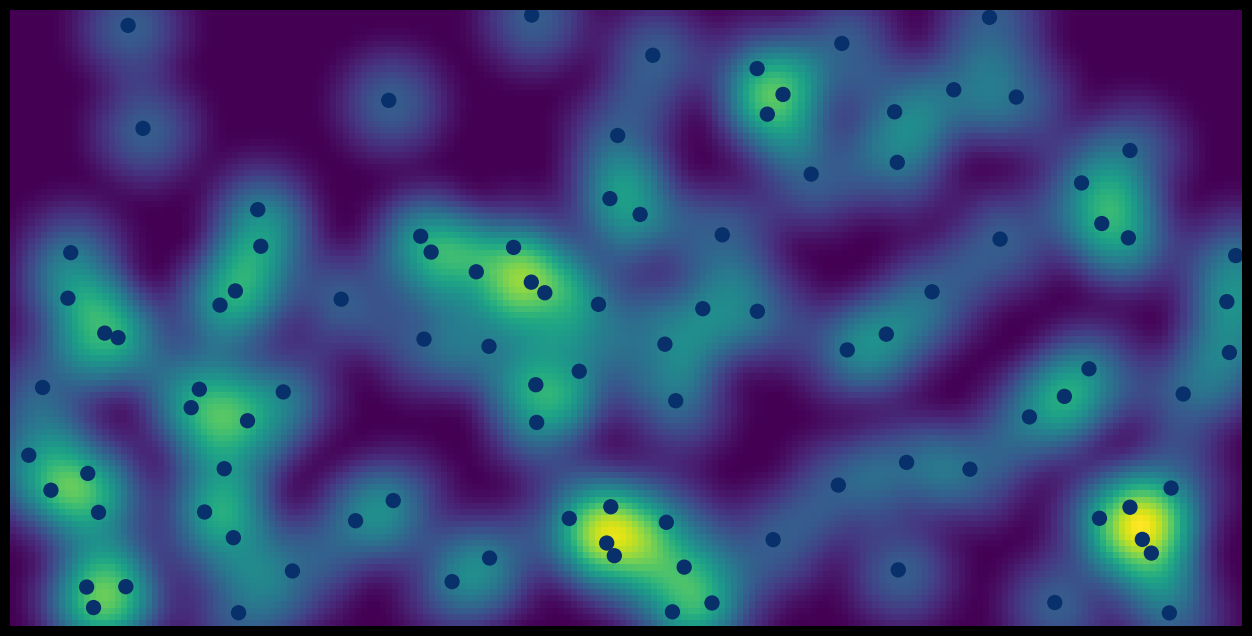

In [13]:
# Color the background with density
x_res = int(100 * DIMENSION_SIZES[0])
y_res = int(100 * DIMENSION_SIZES[1])
density_field = np.zeros((y_res, x_res))
for i in range(x_res):
    for j in range(y_res):
        density_field[j, i] = roh_s(
            np.array([i/x_res * DIMENSION_SIZES[0], j/y_res * DIMENSION_SIZES[1]])
        )
fig, ax = plt.subplots(figsize=(8 * DIMENSION_SIZES[0] / DIMENSION_SIZES[1], 8))
initialize_particle_subplot(fig, ax, particles)
ax.imshow(density_field, extent=[0, DIMENSION_SIZES[0], 0, DIMENSION_SIZES[1]])
plt.show()

## Pressure calculation

Now that we have the density field, we can calculate the pressure field. Pressure basically arises from the density of the fluid. The pressure wants to achieve the rest density `RHO_0`. So if the density is higher than the rest density, the pressure will be positive. If the density is lower than the rest density, the pressure will be negative. Moreover, the pressure is also scaled by the stiffness of the fluid, which is defined by the gas constant `K`.
Normally, fluids are incompressible, which means that `K` should be set to a very high value. Sadly, this will either make the simulation unstable or we will need to use a very small timestep `DT` to keep the simulation stable. This is why we will set `K` to a lower value.

The pressure at a point in space is calculated by the following formula:

$p = k \bigl(\rho - \rho_0\bigr)$

In [14]:
# Define K and ROH_O
K = 5.0 # Pa (tuned for this simulation)
ROH_0 = 1000.0 # kg/m^3

In [15]:
def p_s(density: float) -> float:
    return K * (density - ROH_0)

Now we will need a new kernel function to calculate the pressure gradient. The pressure gradient is the steepness of the pressure field. It is used to calculate the forces acting on the particles. We can't use the poly6 kernel function since it is smooth at the top. We need a kernel function that has a sharp peak at $r=0$ because we want the forces to be very strong if the particles are close to each other. Thus, we will introduce the spiky kernel function.

The spiky kernel function is defined as follows:

$W_{\mathrm{spiky}}(\mathbf{r},h) = \frac{15}{\pi h^6} \begin{cases} (h - r)^3 & 0 \le r \le h \\ 0 & \text{otherwise} \end{cases}$

In [16]:
def W_spiky(r: np.ndarray, h: float=H) -> float:
    r_len = np.linalg.norm(r)
    if 0 <= r_len <= h:
        return 15 / (np.pi * h**6) * (h - r_len)**3
    else:
        return 0.0

The thing we are really interested in is the partial derivative of the spiky kernel function with respect to r. This is then used to calculate the pressure gradient.

The partial derivative of the spiky kernel function with respect to $r$ is given by the following formula. This function returns a scalar:

$\frac{\partial}{\partial r} W_{\mathrm{spiky}}(\mathbf{r}, h)  = -\frac{45}{\pi h^6} \begin{cases} (h - r)^2 & 0 \le r \le h \\ 0 & \text{otherwise} \end{cases}$

In [17]:
def W_spiky_derivative(r: np.ndarray, h: float) -> float:
    r_len = np.linalg.norm(r)
    if 0 <= r_len <= h:
        return -45 / (np.pi * h**6) * (h - r_len)**2
    else:
        return 0.0

Since our kernel functions are all radial symmetric, our function only depends on $\mathbf{r}$ through its magnitude $r = \lVert \mathbf{r} \rVert$. This means that our gradient is given by:

$ \nabla W = \frac{\partial W}{\partial r} \frac{\mathbf{r}}{r} $

And the pressure gradient $\nabla p$ at a point in space is calculated by the following formula. This function returns a vector:

$\nabla W_{\mathrm{spiky}}(\mathbf{r}, h) = -\frac{45}{\pi h^6} \begin{cases} (h - r)^2 \dfrac{\mathbf{r}}{r} & 0 \le r \le h \\ 0 & \text{otherwise} \end{cases}$

In [18]:
# This function will automatically return the gradient of the kernel function
def W_spiky_grad(r: np.ndarray, h: float) -> np.ndarray:
    r_len = np.linalg.norm(r)
    if 0 <= r_len <= h:
        return -45 / (np.pi * h**6) * (h - r_len)**2 * r / r_len
    else:
        return np.zeros_like(r)

Let's plot the spiky kernel function and the derivative of the spiky kernel function. I think not much needs to be said about the spiky kernel function. It has a sharp peak at $r=0$ and is zero at the smoothing radius $h$.

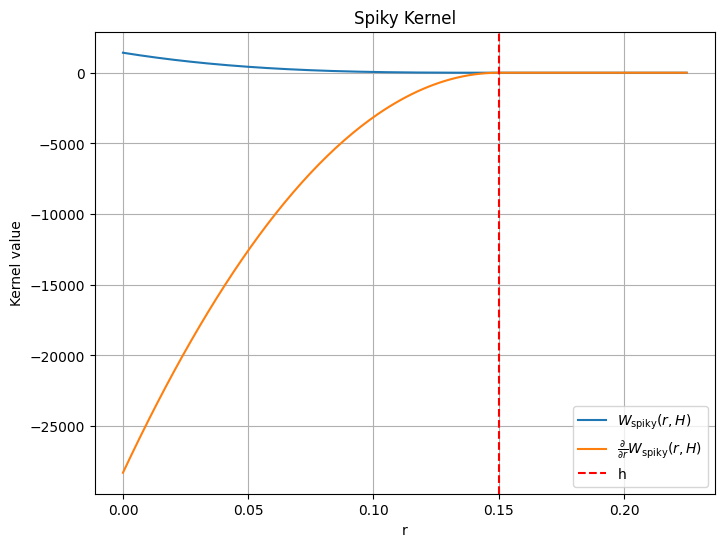

In [19]:
# We only need positive values of r since distances are always positive
r_vals = np.linspace(0, 1.5 * H, 200)
values = [W_spiky(np.array([r, 0]), H) for r in r_vals]
values_derivative = [W_spiky_derivative(np.array([r, 0]), H) for r in r_vals]

plt.figure(figsize=(8, 6))
plt.plot(r_vals, values, label=r'$W_{\mathrm{spiky}}(r,H)$')
plt.plot(r_vals, values_derivative, label=r'$\frac{\partial}{\partial r} W_{\mathrm{spiky}}(r, H)$')
plt.axvline(x=H, linestyle='--', color='red', label='h')

plt.xlabel("r")
plt.ylabel("Kernel value")
plt.title("Spiky Kernel")
plt.legend()
plt.grid(True)
plt.show()

Now let us fill in the attributes `density` and `pressure` of the particles. We will calculate the density and pressure at each particle location and store it in the respective attribute. 

We will first calculate the density:

In [20]:
def calculate_density(particles: list[Particle]) -> None:
    for p_i in particles:
        p_i.density = 0.0
        for p_j in particles:
            p_i.density += p_j.mass * W_poly6(p_i.position - p_j.position, H)
calculate_density(particles)

Now we use the density to calculate the pressure at each particle location:

In [21]:
def calculate_pressure(particles: list[Particle]) -> None:
    for p_i in particles:
        p_i.pressure = p_s(p_i.density)
calculate_pressure(particles)

After the every particle has its density and pressure calculated, we can calculate the pressure forces acting on the particles. For every particle $p_i$, we iterate over all particles $p_j$. The first component of the pressure force is the pressure gradient we calculated earlier. We will calculate the pressure gradient with the difference in position between the particles. Then we need to scale it with the pressure over the density. 

But here is a slight catch. Since all forces acting on the particles need to be symmetrical, meaning that the force acting on particle $p_i$ from particle $p_j$ is the same as the force acting on particle $p_j$ from particle $p_i$ (Newton's third law), we need to average the pressure between the two particles, because the density and pressure at the particle location might be different.

Lastly, we multiply with the mass of the particle, sum up all the forces and put a negative sign in front of it since we want the force to act against the pressure gradient.

Thus, our pressure force acting on a particle is given by the following formula:

$\mathbf{f}_i^{\mathrm{pressure}} = - \sum_j \, m_j \, \frac{p_i + p_j}{2 \, \rho_j} \,\nabla W\bigl(\mathbf{r}_i - \mathbf{r}_j, h\bigr)$

In [22]:
def calculate_pressure_forces(particles: list[Particle]) -> np.ndarray:
    pressure_forces = np.zeros((N, DIMENSIONS)) # Array to store pressure forces for each particle
    for idx, p_i in enumerate(particles):
        f_pressure = np.zeros(DIMENSIONS)
        for p_j in particles:
            if p_i == p_j: # Skip the particle itself to avoid division by zero
                continue
            f_pressure += - p_j.mass * (p_i.pressure + p_j.pressure) / (2 * p_j.density) * W_spiky_grad(p_i.position - p_j.position, H)
        pressure_forces[idx] = f_pressure
    return pressure_forces
pressure_forces = calculate_pressure_forces(particles)

When taking a look at the pressure field and the resulting forces we can notice a few things:
- If particles are close to each other, the pressure will be high and the forces will be strong. This is because the density is high and the pressure is high.
- If particles are still close to each other but not too close, the pressure will actually pull the particles together. This is because the pressure wants to get to the rest density `RHO_0`.
- If particles are really far away from each other and outside each other's smoothing radius, there will be no pressure force acting on the particles.

The part with the lonely particles is actually a problem. They have no chance to actually move because there are no forces acting on them except if some other particles come close to them. We will later solve this problem by adding more particles to the simulation. Furthermore, we will add gravity to the simulation, which will also help to squash the particles together.

But with more particles we run in another problem. Increasing the number of particles will increase the number of calculations we need to do. Even worse the number of calculations will increase with the square of the number of particles. Thus, our simulation currently runs in $O(N^2)$ time complexity. This is not good. But before tackling this problem, let's first implement the viscosity forces.

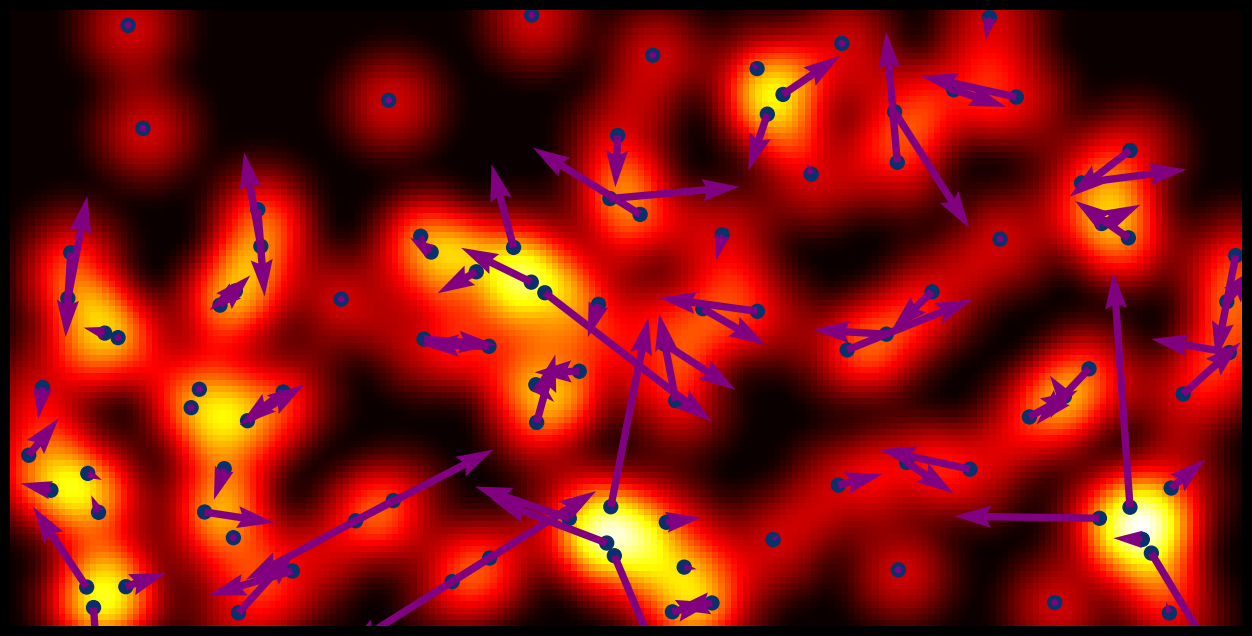

In [23]:
# Visualize pressure forces
x_res = int(100 * DIMENSION_SIZES[0])
y_res = int(100 * DIMENSION_SIZES[1])
pressure_field = np.zeros((y_res, x_res))
for i in range(x_res):
    for j in range(y_res):
        pressure_field[j, i] = p_s(density_field[j, i])
fig, ax = plt.subplots(figsize=(8 * DIMENSION_SIZES[0] / DIMENSION_SIZES[1], 8))
initialize_particle_subplot(fig, ax, particles)
ax.imshow(pressure_field, cmap='hot', extent=[0, DIMENSION_SIZES[0], 0, DIMENSION_SIZES[1]])
ax.quiver([p.position[0] for p in particles], [DIMENSION_SIZES[1] - p.position[1] for p in particles], pressure_forces[:, 0], -pressure_forces[:, 1], color='purple')
plt.show()

## Viscosity calculation

Water and honey are both fluids, but they behave very differently. Water is very fluid and flows easily. Honey is very viscous and flows very slowly. This is because of the viscosity of the fluid. Viscosity is the resistance of a fluid to flow. The higher the viscosity, the slower the fluid will flow. Viscosity is caused by the friction between the molecules of the fluid. The friction between the molecules will cause the fluid to stick together and flow slower.

In other words we need to add a force that will make the particles close to each other move at similar velocities. This will make the fluid flow more smoothly. This force is called the viscosity force. The viscosity force is calculated by the following formula:

$\mathbf{f}_i^{\mathrm{viscosity}} = \mu \sum_j m_j \,\frac{\mathbf{v}_j - \mathbf{v}_i}{\rho_j}\,\nabla^2 W\bigl(\mathbf{r}_i - \mathbf{r}_j, h\bigr)$

$\nabla^2 W$ is the Laplacian of the kernel function. The Laplacian is a measure of the curvature of a function. It is used to calculate the divergence of a vector field. This is exactly what we need. Since if the velocity of one particle is very different from the velocity of another particle, then the viscosity force will be high.

We will again use another kernel function for the viscosity force. The viscosity kernel function is defined as follows:

$W_{\mathrm{viscosity}}(r,h) = \frac{15}{2\pi h^3}\begin{cases}\dfrac{r^3}{2 h^3} \;+\; \dfrac{r^2}{h^2} \;+\; \dfrac{r}{2 h} \;-\; 1 & 0 \le r \le h\\0 & \text{otherwise}\end{cases}$

Its laplacian is given by the following formula:

$\nabla^2 W(r,h) = \frac{45}{\pi h^6}\bigl(h - r\bigr)$

If you are interested in the topic of laplacians, I can recommend the following video from the YouTube channel 3Blue1Brown:

<iframe width="560" height="315" src="https://www.youtube.com/embed/ly4S0oi3Yz8" title="3Blue1Brown - Laplacians" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>

But for now, let's just accept that the laplacian of the viscosity kernel function is given by the formula above.

In [24]:
def W_viscosity_laplacian(r: np.ndarray, h: float) -> float:
    r_len = np.linalg.norm(r)
    if 0 <= r_len <= h:
        return 45 / (np.pi * h**6) * (h - r_len)
    else:
        return 0.0

The following implements the calculation of the viscosity forces. The viscosity will be multiplied by the coefficient `MU`.

In [25]:
# Define MU
MU = 0.1 # Pa * s

In [26]:
def calculate_viscosity_forces(particles: list[Particle]) -> np.ndarray:
    viscosity_forces = np.zeros((N, DIMENSIONS))
    for idx, p_i in enumerate(particles):
        f_viscosity = np.zeros(DIMENSIONS)
        for p_j in particles:
            if p_i == p_j: # Skip the particle itself to avoid division by zero
                continue
            f_viscosity += MU * p_j.mass * (p_j.velocity - p_i.velocity) / p_j.density * W_viscosity_laplacian(p_i.position - p_j.position, H)
        viscosity_forces[idx] = f_viscosity
    return viscosity_forces

If we calculate the viscosity forces now, nothing will happen, since the velocity of the particles is zero. We will add a random velocity to some particles to see the viscosity forces in action.

In [27]:
# Add random velocities to some particles and then calculate viscosity forces
for p in particles:
    p.velocity = np.zeros(DIMENSIONS)
    if np.random.rand() < 0.1:
        p.velocity = np.random.randn(DIMENSIONS) * 0.01
viscosity_forces = calculate_viscosity_forces(particles)

In the visualization the green arrows represent the velocity vector of the particles. The cyan arrows represent the viscosity forces acting on the particles. It might look chaotic at first but if you look closely you will notice a clear pattern:
- Many particles with a green arrow will have a cyan arrow pointing in opposite direction. This is especially true for particles that are close to idle particles. That means that the viscosity force will try to counteract the velocity of the particle since the idle particles close to it are not moving.
- Furthermore, the idle particles close to a particle with a velocity will have a cyan arrow pointing in the same direction as the green velocity arrow. This is because the viscosity force will try to make the particles close to each other move at similar velocities.
- If you are lucky you might see some particles with the same velocity close to each other. In that case the viscosity force will be very low because they are already moving at similar velocities.

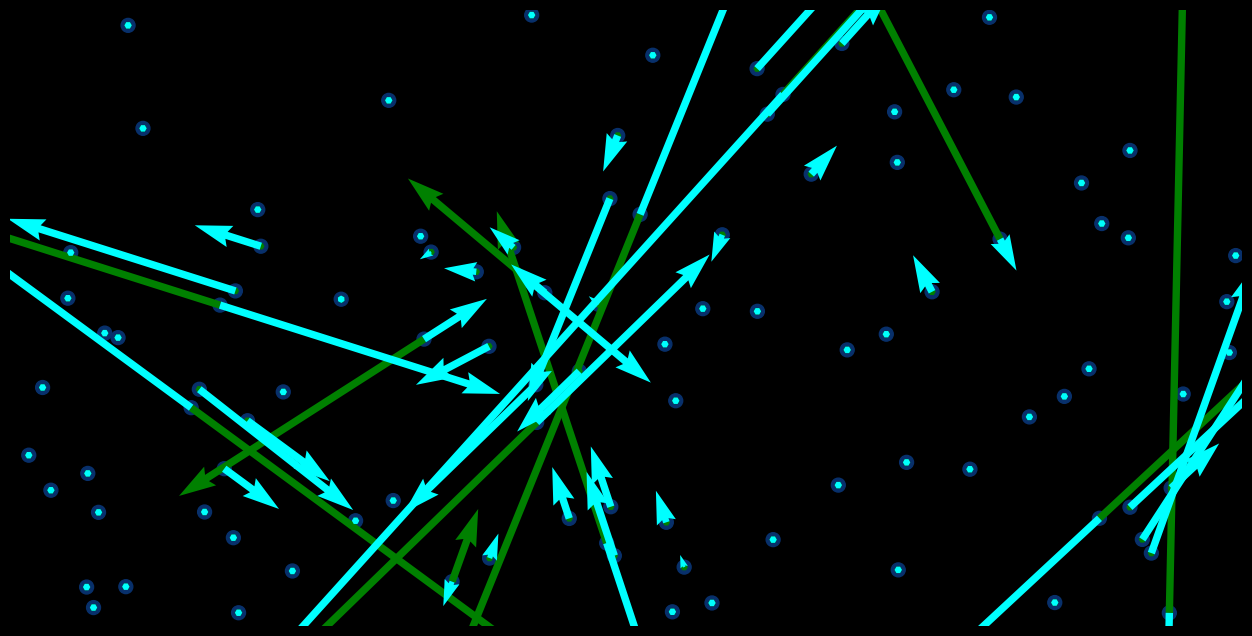

In [28]:
# Visualize viscosity forces
fig, ax = plt.subplots(figsize=(8 * DIMENSION_SIZES[0] / DIMENSION_SIZES[1], 8))
initialize_particle_subplot(fig, ax, particles)
# Velocity vectors are colored green
ax.quiver([p.position[0] for p in particles], [DIMENSION_SIZES[1] - p.position[1] for p in particles], [p.velocity[0] for p in particles], [-p.velocity[1] for p in particles], color='green')
# Force vectors are colored cyan
ax.quiver([p.position[0] for p in particles], [DIMENSION_SIZES[1] - p.position[1] for p in particles], viscosity_forces[:, 0], -viscosity_forces[:, 1], color='cyan')
plt.show()

In [29]:
# Let's reset the velocities
for p in particles:
    p.velocity = np.zeros(DIMENSIONS)

## Grid

Now before creating any animation or running the simulation, we really need to get away from the $O(N^2)$ time complexity. We will divide the space into a grid of cells. Each cell will contain a list of particles that are in that cell. This way we can easily find the particles that are close to each other and only calculate the forces between them. This will reduce the time complexity from $O(N^2)$ to $O(N)$.

Let us define hyperparameters for the grid.

- `CELL_SIZE` is the size of the cells in the grid. We will set this to the value of the smoothing radius `H`.

- `NUM_CELLS` is a list of integers that defines the number of cells in each dimension.

- `CELL_STRIDES` will be needed to calculate the index of the cell a particle is in.

- `NEIGHBOR_OFFSETS` is a list of tuples that defines the offsets of the neighboring cells. This will be used to find the neighboring cells of a particle. We will use a 3x3 grid of neighboring cells. This means that we will check the cell the particle is in and the 8 neighboring cells around it.

- `GRID_CELLS` is our actual grid. It is a list of lists that contains the particles in each cell. The length of the list is equal to the number of cells in the grid. Each cell will contain a list of particles that are in that cell.

In [30]:
CELL_SIZE = H
NUM_CELLS = [int(DIMENSION_SIZES[d] / CELL_SIZE) for d in range(DIMENSIONS)]
print("Number of cells:", NUM_CELLS)

# Precompute strides for fast flat indexing
CELL_STRIDES = [int(np.prod(NUM_CELLS[d+1:])) for d in range(DIMENSIONS)]
print("Cell strides:", CELL_STRIDES)
# Precompute neighbor-cell offsets
NEIGHBOR_OFFSETS = list(itertools.product([-1, 0, 1], repeat=DIMENSIONS))
print("Neighbor offsets:", NEIGHBOR_OFFSETS)

# Allocate GRID_CELLS for fast access to particles in each cell
GRID_CELLS: list[list[Particle]] = [[] for _ in range(np.prod(NUM_CELLS))]

Number of cells: [13, 6]
Cell strides: [6, 1]
Neighbor offsets: [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 0), (0, 1), (1, -1), (1, 0), (1, 1)]


The following functions will be used to calculate the index of the cell a particle is in, update the grid and to find the neighboring particles. The function `get_cell_index` will return the index of the cell a particle is in. The function `update_grid` will pack the particles into the grid list. Lastly the function `get_neighbouring_particles` will return the list of neighboring particles of a particle and that is exactly what we want.

In [31]:
def get_cell_index(position: np.ndarray) -> int:
    coords = []
    for d in range(DIMENSIONS):
        # Calculate cell index for each dimension
        # Use integer division to get the cell index
        c = int(position[d] // CELL_SIZE)
        # Clamp to valid range
        coords.append(min(max(c, 0), NUM_CELLS[d] - 1))
    # combine with precomputed strides
    idx = sum(c * stride for c, stride in zip(coords, CELL_STRIDES))
    return idx

In [32]:
def update_grid(particles: list[Particle]) -> None:
    # Clear old assignments
    for cell in GRID_CELLS:
        cell.clear()
    # Reassign every particle
    for p in particles:
        ci = get_cell_index(p.position)
        GRID_CELLS[ci].append(p)

In [33]:
def get_neighbor_particles(p: Particle) -> list[Particle]:
    # get central cell coords once
    base_coords = []
    for d in range(DIMENSIONS):
        base_coords.append(int(p.position[d] // CELL_SIZE))
    neighbors = []
    # iterate over all neighbor offsets
    for off in NEIGHBOR_OFFSETS:
        coords = tuple(base_coords[d] + off[d] for d in range(DIMENSIONS))
        # check if the coordinates are within bounds
        if all(0 <= coords[d] < NUM_CELLS[d] for d in range(DIMENSIONS)):
            idx = sum(coords[d] * CELL_STRIDES[d] for d in range(DIMENSIONS))
            neighbors.extend(GRID_CELLS[idx])
    # remove duplicates
    return list(set(neighbors))

Now we visualize the grid and take a look at some particles and their neighboring particles.

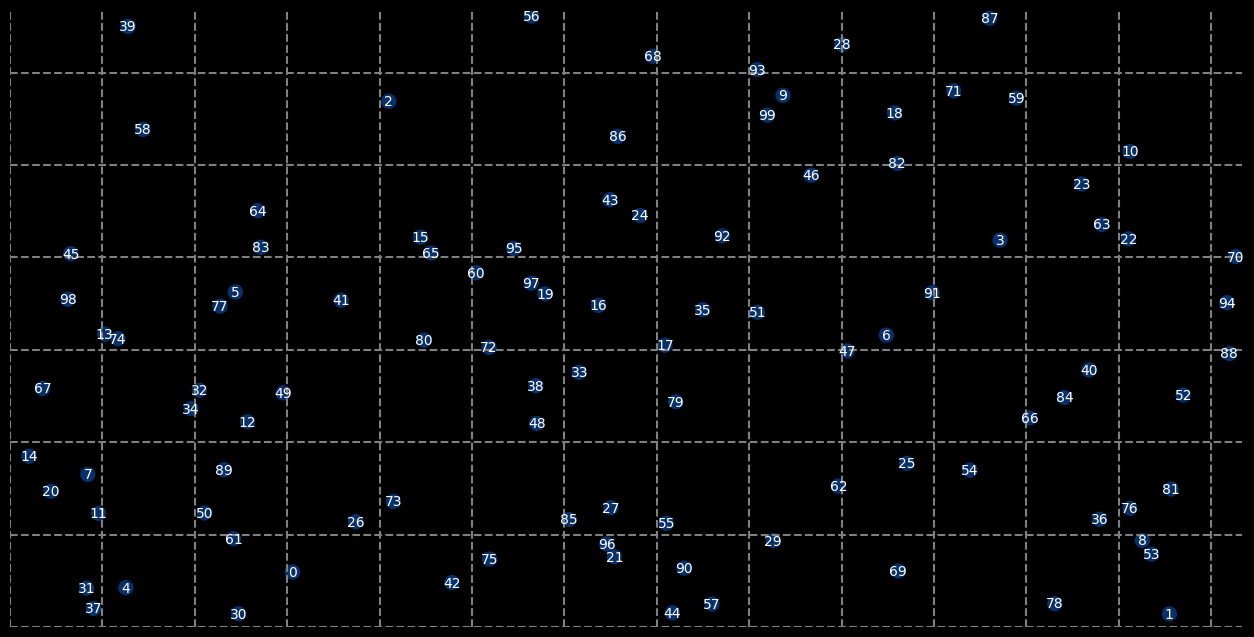

Particle 0 is in cell 23 with neighbor particles [26, 0, 50, 61, 30, 73, 42]
Particle 1 is in cell 77 with neighbor particles [78, 36, 1, 81, 8, 53, 76]
Particle 2 is in cell 24 with neighbor particles [56, 2]
Particle 3 is in cell 62 with neighbor particles [3, 47, 91, 18, 82, 6, 40, 63, 23]
Particle 4 is in cell 11 with neighbor particles [4, 37, 7, 50, 61, 30, 20, 31, 11]


In [34]:
# Assign particles to cells
update_grid(particles)

# Visualize grid
fig, ax = plt.subplots(figsize=(8 * DIMENSION_SIZES[0] / DIMENSION_SIZES[1], 8))
initialize_particle_subplot(fig, ax, particles)

# Draw grid
for x in range(NUM_CELLS[0] + 1):
    ax.axvline(x * H, color='grey', linestyle='--')
for y in range(NUM_CELLS[1] + 1):
    ax.axhline(y * H, color='grey', linestyle='--')

# Number the particles
for idx, particle in enumerate(particles):
    ax.text(particle.position[0], DIMENSION_SIZES[1] - particle.position[1], str(idx), color='white', ha='center', va='center')

plt.show()

# Print some cells and their contents
for idx, p in enumerate(particles[:5]):
    cell_index = get_cell_index(p.position)
    neighbor_particles = get_neighbor_particles(p)
    neighbor_indices = [particles.index(neighbor) for neighbor in neighbor_particles]
    print(f"Particle {idx} is in cell {cell_index} with neighbor particles {neighbor_indices}")

Of course, we need to redefine the functions `calculate_density`, `calculate_pressure_forces` and `calculate_viscosity_forces` to use the grid instead of iterating over all particles by calling out `get_neighbor_particles` function.

In [35]:
def calculate_density_grid(particles: list[Particle]):
    for p_i in particles:
        p_i.density = 0.0
        neighbours = get_neighbor_particles(p_i) # Get neighbors from the grid
        for p_j in neighbours:
            p_i.density += p_j.mass * W_poly6(p_i.position - p_j.position, H)

In [36]:
def calculate_pressure_forces_grid(particles: list[Particle]) -> np.ndarray:
    pressure_forces = np.zeros((N, DIMENSIONS))
    for idx, p_i in enumerate(particles):
        f_pressure = np.zeros(DIMENSIONS)
        neighbours = get_neighbor_particles(p_i) # Get neighbors from the grid
        for p_j in neighbours:
            if p_i == p_j:
                continue
            f_pressure += - p_j.mass * (p_i.pressure + p_j.pressure) / (2 * p_j.density) * W_spiky_grad(p_i.position - p_j.position, H)
        pressure_forces[idx] = f_pressure
    return pressure_forces

In [37]:
def calculate_viscosity_forces_grid(particles: list[Particle]) -> np.ndarray:
    viscosity_forces = np.zeros((N, DIMENSIONS))
    for idx, p_i in enumerate(particles):
        f_viscosity = np.zeros(DIMENSIONS)
        neighbours = get_neighbor_particles(p_i) # Get neighbors from the grid
        for p_j in neighbours:
            if p_i == p_j:
                continue
            f_viscosity += MU * p_j.mass * (p_j.velocity - p_i.velocity) / p_j.density * W_viscosity_laplacian(p_i.position - p_j.position, H)
        viscosity_forces[idx] = f_viscosity
    return viscosity_forces

Let's see how much the grid actually speeds up the simulation. We will compare the runtime of `calculate_density` with `calculate_density_grid` for different Numbers of particles.

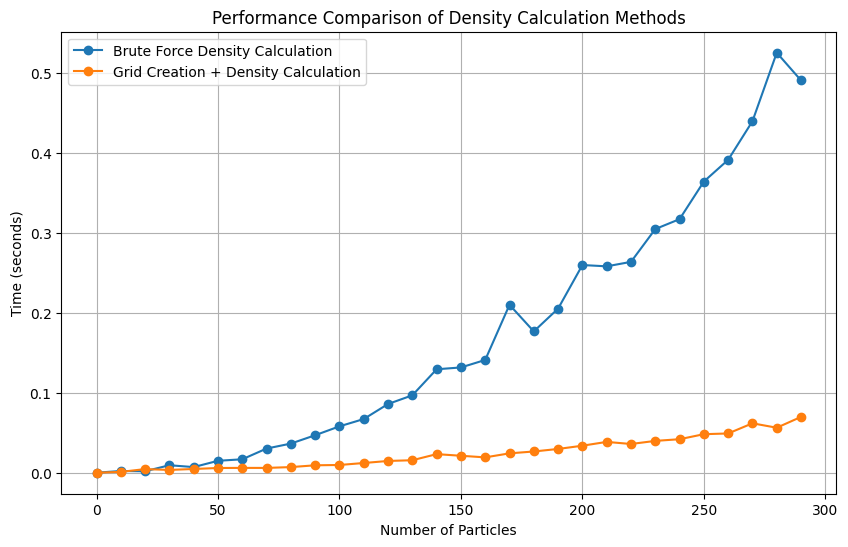

In [38]:
number_of_particles = np.arange(0, 300, 10)
timings_brute_force = []
timings_grid_and_density_calculation = []

for n in number_of_particles:
    # Initialize particles
    particles = []
    for _ in range(n):
        position = np.random.rand(DIMENSIONS) * DIMENSION_SIZES
        velocity = np.zeros(DIMENSIONS)
        particles.append(Particle(position, velocity, PARTICLE_MASS))

    # Brute force
    start = time.time()
    calculate_density(particles)
    end = time.time()
    timings_brute_force.append(end - start)

    # Grid creation and density calculation
    start = time.time()
    update_grid(particles)
    calculate_density_grid(particles)
    end = time.time()
    timings_grid_and_density_calculation.append(end - start)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(number_of_particles, timings_brute_force, label='Brute Force Density Calculation', marker='o')
plt.plot(number_of_particles, timings_grid_and_density_calculation, label='Grid Creation + Density Calculation', marker='o')
plt.xlabel('Number of Particles')
plt.ylabel('Time (seconds)')
plt.title('Performance Comparison of Density Calculation Methods')
plt.legend()
plt.grid(True)
plt.show()

Would you look at that! While the brute force method grows quadratically, the grid method grows linearly. Of course, there are minor fluctuations in the runtime, but the overall trend is clear.

## Time integration

Now it is time to create the animation. But currently, the particles have no boundaries and will just fly off the screen. For simplicity, we will just reflect the particles at the boundaries. This means that if a particle hits a boundary, it will just bounce back with a slight loss of velocity. A raduis is used to keep some distance to the boundary.

In [39]:
def check_boundary_conditions(particle: Particle, damping: float=-0.5, radius=1e-3) -> None:
    for d in range(DIMENSIONS):
        if particle.position[d] - radius < 0:
            particle.velocity[d] *= damping
            particle.position[d] = radius
        elif particle.position[d] > DIMENSION_SIZES[d]:
            particle.velocity[d] *= damping
            particle.position[d] = DIMENSION_SIZES[d] - radius

Let's build our final animation. We will use the `FuncAnimation` class from the `matplotlib` library to create the animation.

Since our algorithm is now optimized, we can increase the number of particles. We will also define `GRAVITY` for our little animation to have the particles falling to the bottom. `ANIMATION_FPS` is self-explanatory and `DT` determines how large the integration steps will be. Increasing `DT` will make the calculation faster but the simulation might get unstable.

We are also going to redefine all the other hyperparameters. Thus, you can play around with them if you like.

In [40]:
N = 150 # Number of particles
PARTICLE_MASS = 1.0 # kg (fluid mass is N * PARTICLE_MASS)
GRAVITY = 9.81 # m/s^2
ANIMATION_FPS = 30 # frames per second
DT = 0.0001 # seconds

DIMENSIONS = 2 # 2D simulation
DIMENSION_SIZES = np.array([2.0, 1.0]) # meters
assert len(DIMENSION_SIZES) == DIMENSIONS

H = 0.15 # m
K = 5.0 # Pa (tuned for this simulation)
ROH_0 = 1000.0 # kg/m^3
MU = 0.1 # Pa * s

# Update the grid parameters
CELL_SIZE = H
NUM_CELLS = [int(DIMENSION_SIZES[d] / CELL_SIZE) for d in range(DIMENSIONS)]
CELL_STRIDES = [int(np.prod(NUM_CELLS[d+1:])) for d in range(DIMENSIONS)]
NEIGHBOR_OFFSETS = list(itertools.product([-1, 0, 1], repeat=DIMENSIONS))
GRID_CELLS: list[list[Particle]] = [[] for _ in range(np.prod(NUM_CELLS))]

In [41]:
# Reinitialize the particles
particles: list[Particle] = []
for _ in range(N):
    # The particles are initialized in the center of the simulation box
    position = np.random.rand(DIMENSIONS) * \
        [DIMENSION_SIZES[0] / 2, DIMENSION_SIZES[1] / 2] + [DIMENSION_SIZES[0] / 4, DIMENSION_SIZES[1] / 4]
    velocity = np.zeros(DIMENSIONS)
    particles.append(Particle(position, velocity, PARTICLE_MASS))

For the animation we will loop over all calculation steps needed each frame. We also use a small trick to make the animation more stable. The trick is to predict the next position of the particles based on the current velocity. After doing the calculations, we will reset the position of the particles to the actual position.

This concludes our SPH simulation. Enjoy the animation!

In [42]:
fig, ax = plt.subplots(figsize=(8 * DIMENSION_SIZES[0] / DIMENSION_SIZES[1], 8))
fig.patch.set_facecolor('black')
plt.close(fig) # Prevents the figure from being displayed

def frame(t):
    # Set the accumulated forces to zero
    for p in particles:
        p.accumulated_force = np.zeros(DIMENSIONS)

    # Save current positions for stable integration (prediction trick)
    old_positions = np.array([p.position for p in particles])

    # Apply gravity to particles
    for p in particles:
        p.accumulated_force[1] += GRAVITY * p.density if p.density is not None else 0.0

    # Apply boundary conditions (prediction trick)
    for p in particles:
        check_boundary_conditions(p)

    # Predict new positions based on the current velocities (prediction trick)
    for p in particles:
        p.position += p.velocity * DT

    # Update grid
    update_grid(particles)

    # Update Density
    calculate_density_grid(particles)

    # Update Pressure
    calculate_pressure(particles)

    # Get pressure forces
    pressure_forces = calculate_pressure_forces_grid(particles)
    for idx, p in enumerate(particles):
        p.accumulated_force += pressure_forces[idx]

    # Get viscosity forces
    viscosity_forces = calculate_viscosity_forces_grid(particles)
    for idx, p in enumerate(particles):
        p.accumulated_force += viscosity_forces[idx]

    # Set the predicted positions back (prediction trick)
    for idx, p in enumerate(particles):
        p.position = old_positions[idx]

    # Integrate the forces to get the new velocities and positions
    for idx, p in enumerate(particles):
        p.velocity += p.accumulated_force / p.density
        p.position += p.velocity * DT

    # Handle boundary conditions
    for p in particles:
        check_boundary_conditions(p)
    
    # Draw particles
    ax.clear()
    ax.set_facecolor('black')
    initialize_particle_subplot(fig, ax, particles)

animate = False
if animate:
    ani = animation.FuncAnimation(fig, frame, frames=range(7*ANIMATION_FPS))
    display(HTML(ani.to_jshtml(fps=ANIMATION_FPS)))

## References

This work is mainly based on the following resources:

- [Particle-Based Fluid Simulation for Interactive Applications](https://matthias-research.github.io/pages/publications/sca03.pdf) by Matthias Müller, David Charypar and Markus Gross.

- [Smoothed Particle Hydrodynamics Techniques for the Physics Based Simulation of Fluids and Solids](https://sph-tutorial.physics-simulation.org/pdf/SPH_Tutorial.pdf) by Dan Koschier, Jan Bender, Barbara Solenthaler, and Matthias Teschner.

- [Particle Simulation using CUDA](https://web.archive.org/web/20140725014123/https://docs.nvidia.com/cuda/samples/5_Simulations/particles/doc/particles.pdf) by Simon Green.